In [2]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
from PIL import Image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pylab import *
import os
import sys

from keras.models import Model
from keras.regularizers import l2
from keras.layers import *

from keras.applications.vgg16 import *
from keras.models import *

import keras.backend as K
import tensorflow as tf
import torch
from tensorflow.keras import regularizers
import cv2  
from tensorflow.keras.callbacks import LearningRateScheduler


C:\Users\James\anaconda3\envs\tf_2.6_py_3.7\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Read image
path = 'C:\\Users\\James\\hwk03_data_new\\train\\pre'
os.chdir(path)
data = []
for i in range(1,301):
    img = Image.open('frame'+str(i)+'.bmp')
    img = np.array(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #改為單一channel 才可執行 equalizeHist
    img = img.astype(np.uint8) # 改為 uint 8 
    img = img[61:567,10:550] # 將上方61個pixel 左方10個pixel 右方90個pixel切除  = (505,540)
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA) #resized 成 (224,224)
    #clahe = cv2.createCLAHE()
    #img = clahe.apply(img)
    img = cv2.equalizeHist(img) # 直方圖均勻化
    img = img / 255  #歸一化
    img = cv2.merge((img,img,img)) #重新疊回3channel
    data.append(img)

In [4]:
data = np.array(data) # shape (N,H,W,C)
data.shape

(300, 224, 224, 3)

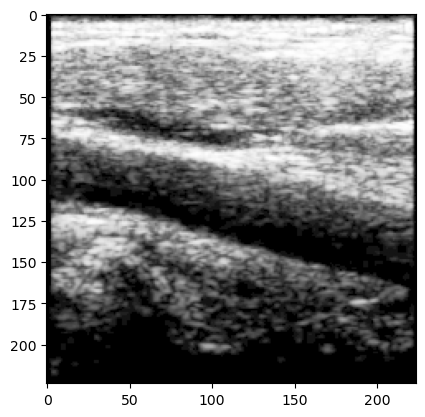

In [5]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(data[26])
plt.show()
#就人眼來說血管有變的明顯一點

In [6]:
# read label
path = 'C:\\Users\\James\\hwk03_data_new\\train\\post'
os.chdir(path)
label = []
for i in range(1,301):
    img = Image.open('frame'+str(i)+'.bmp_ROI.bmp')
    img = np.array(img, dtype='f') # 改為 0 ,1
    img = img[61:567,10:550] # 跟image 採一樣crop
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA) #resized 成 (224,224)
    img[img > 0] = 1 #內插後，有些數值會跑掉。將大於0的pixel，通通 = 1
    img = np.expand_dims(img,axis=2) # channel = 1 才可augmentation，2無法。
    label.append(img)

In [7]:
label = np.array(label) # channel = 1 ，為了 augmentation ，augmentation做完轉回 channel = 2
label.shape

(300, 224, 224, 1)

In [8]:
# 雙線性插值起始值，為了讓deconv的圖像變得更精細
class BilinearInitializer(keras.initializers.Initializer):
    '''Initializer for Conv2DTranspose to perform bilinear interpolation on each channel.'''
    def __call__(self, shape, dtype=None, **kwargs):
        kernel_size, _, filters, _ = shape
        arr = np.zeros((kernel_size, kernel_size, filters, filters))
        ## make filter that performs bilinear interpolation through Conv2DTranspose
        upscale_factor = (kernel_size+1)//2
        if kernel_size % 2 == 1:
            center = upscale_factor - 1
        else:
            center = upscale_factor - 0.5
        og = np.ogrid[:kernel_size, :kernel_size]
        kernel = (1-np.abs(og[0]-center)/upscale_factor) * \
                 (1-np.abs(og[1]-center)/upscale_factor) # kernel shape is (kernel_size, kernel_size)
        for i in range(filters):
            arr[..., i, i] = kernel
        return tf.convert_to_tensor(arr, dtype=dtype)

In [ ]:
# FCN-8s model 採用VGG16 model 之5 conv block 進行改造。
#採用 imagenet pretrain weight 當起始值 ，fine_tuning
#採用課本的FCN-8s模型， 先從block 5 pooling output。 做一層 conv2d 得到 7 * 7 * 2
#接著deconv(transpose)將其放大2倍，得到14 * 14 * 2

#取出block 4 pool output，做conv2d ，得到14 * 14 * 2
#將兩者做skip_connection

#將合併後結果deconv(transpose)將其放大2倍，得到28 * 28 * 2

#取出block 3 pool output，做conv2d ，得到28 * 28 * 2
#再做一次skip_connection

#最後將其deconv放大8倍，得到224 * 224 * 2

In [9]:
def fcn():
    base_model = tf.keras.applications.VGG16(weights='imagenet',
                                            input_shape=(224,224,3),
                                            include_top=False)
    base_model.summary()
    base_model.trainable = True #fine tuning
    out = base_model.output # block5_pooling output
    
    # 先從vgg output做一層conv2D 。得到 7 * 7 * Class
    x1 = tf.keras.layers.Conv2D(2, (1, 1), activation='relu', padding='same', name="score5")(out)
    # transpose將其放大2倍，14 * 14 * 2
    x1 = tf.keras.layers.Conv2DTranspose(2,
                                        kernel_size=(4,4), 
                                        strides=(2,2),
                                        padding='same',
                                        activation='linear',
                                        use_bias=False,
                                        kernel_regularizer=regularizers.L2(0.0001),
                                        kernel_initializer=BilinearInitializer())(x1)
    #取出block 4 pool，做conv2d 
    y = keras.layers.Conv2D(filters=2, kernel_size=(1,1), strides=(1,1), padding='same', activation='linear',
                            kernel_initializer=keras.initializers.Zeros(),
                            kernel_regularizer=regularizers.L2(0.0001),
                            name='score4')(base_model.get_layer('block4_pool').output)
    #skip connection
    x = keras.layers.Add(name='skip4')([x1, y])
    
    
    #將合併後結果放大2倍
    x2 = tf.keras.layers.Conv2DTranspose(2,
                                        kernel_size=(4,4), 
                                        strides=(2,2),
                                        padding='same',
                                        activation='linear',
                                        use_bias=False,
                                        kernel_regularizer=regularizers.L2(0.0001),
                                        kernel_initializer=BilinearInitializer())(x)
    
    
    y = keras.layers.Conv2D(filters=2, kernel_size=(1,1), strides=(1,1), padding='same', activation='linear',
                            kernel_initializer=keras.initializers.Zeros(),
                            kernel_regularizer=regularizers.L2(0.0001),
                            name='score3')(base_model.get_layer('block3_pool').output)
    
    x = keras.layers.Add(name='skip3')([x2, y])
    
    x = keras.layers.Conv2DTranspose(filters=2, kernel_size=(8,8), strides=(8,8),
                                     padding='same', use_bias=False, activation='softmax',
                                     kernel_initializer=BilinearInitializer(),
                                     kernel_regularizer=regularizers.L2(0.0001),
                                     name='fcn8')(x)
    
    model = tf.keras.models.Model(inputs=base_model.input,
                               outputs=x)
    model.summary()
    
    return model

In [10]:
model = fcn()

Model: "vgg16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0     

In [11]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(data,label, test_size=0.20)
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)

(240, 224, 224, 3) (240, 224, 224, 1)
(60, 224, 224, 3) (60, 224, 224, 1)


In [12]:
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
# augmentation

# label 和 image 必須採一樣的轉換，set same seed，bath_size = 2
class InputGenerator(Sequence):
    """Wrapper of 2 ImageDataGenerator"""

    def __init__(self, X1, X2, batch_size = 2):
         # Keras generator
        self.generator = ImageDataGenerator(rotation_range=20, 
                                            horizontal_flip=True,
                                            width_shift_range=0.1,
                                            height_shift_range=0.1,
                                            shear_range=1.25,
                                            zoom_range=0.1,
                                            fill_mode='nearest')

            # Real time input data augmentation
        self.genX1 = self.generator.flow(X1, batch_size=batch_size, seed=1)
        self.genX2 = self.generator.flow(X2, batch_size=batch_size, seed=1)

    def __len__(self):
        """It is mandatory to implement it on Keras Sequence"""
        return self.genX1.__len__()

    def __getitem__(self, index):
        """Getting items from the 2 generators and packing them"""
        X1_batch = self.genX1.__getitem__(index)
        mask = self.genX2.__getitem__(index)


        y = to_categorical(mask, 2)  # 做完轉換後，將label 轉為 channel = 2 

        return X1_batch, y

In [13]:
#valid不用做特別轉換，只是將之包起來
class validGenerator(Sequence):
    """Wrapper of 2 ImageDataGenerator"""

    def __init__(self, X1, X2, batch_size = 2):
        # Keras generator
        self.generator = ImageDataGenerator()
        # Real time multiple input data augmentation
        # Real time multiple input data augmentation
        self.genX1 = self.generator.flow(X1, batch_size=batch_size, seed=1)
        self.genX2 = self.generator.flow(X2, batch_size=batch_size, seed=1)
    def __len__(self):
        """It is mandatory to implement it on Keras Sequence"""
        return self.genX1.__len__()

    def __getitem__(self, index):
        """Getting items from the 2 generators and packing them"""
        X1_batch = self.genX1.__getitem__(index)
        mask = self.genX2.__getitem__(index)
        
        
        y = to_categorical(mask, 2)

        return X1_batch, y

In [14]:
train_batch = InputGenerator(X_train, y_train, batch_size = 2) 
val_batch = validGenerator(X_valid, y_valid, batch_size = 2) 

In [15]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-4, decay=0.0) #優化採用adam ，起始直因batch size小。取小一點。

In [16]:
from keras.callbacks import EarlyStopping

# early stop : 15個epoch val loss沒有減少，停止訓練
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=15,
    verbose=0,
    mode="min")

In [17]:
# lr scheduler 每過10個epoch，降低lr。lr從大至小，學習步伐越來越小，直至收斂。
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [18]:
callback2 = LearningRateScheduler(scheduler)

In [19]:
'''
ALPHA = 0.8
GAMMA = 2

def FocalLoss(y_true, y_pred, alpha=ALPHA, gamma=GAMMA):    
    
    inputs = K.flatten(y_pred)
    targets = K.flatten(y_true)
    
    BCE = K.binary_crossentropy(targets, inputs)
    BCE_EXP = K.exp(-BCE)
    focal_loss = K.mean(alpha * K.pow((1-BCE_EXP), gamma) * BCE)
    
    return focal_loss
'''

'\nALPHA = 0.8\nGAMMA = 2\n\ndef FocalLoss(y_true, y_pred, alpha=ALPHA, gamma=GAMMA):    \n    \n    inputs = K.flatten(y_pred)\n    targets = K.flatten(y_true)\n    \n    BCE = K.binary_crossentropy(targets, inputs)\n    BCE_EXP = K.exp(-BCE)\n    focal_loss = K.mean(alpha * K.pow((1-BCE_EXP), gamma) * BCE)\n    \n    return focal_loss\n'

In [20]:
'''
def IoUcoef(y_true, y_pred):
    
    #flatten label and prediction tensors
    T = K.flatten(y_true)
    P = K.flatten(y_pred)
    
    intersection = K.sum(T * P)
    IoU = (intersection+1e-6) / (K.sum(P) +  K.sum(T)-intersection+1e-6)
    
    return IoU

def IoUloss(y_true, y_pred):
    return 1-IoUcoef(y_true, y_pred)
'''

'\ndef IoUcoef(y_true, y_pred):\n    \n    #flatten label and prediction tensors\n    T = K.flatten(y_true)\n    P = K.flatten(y_pred)\n    \n    intersection = K.sum(T * P)\n    IoU = (intersection+1e-6) / (K.sum(P) +  K.sum(T)-intersection+1e-6)\n    \n    return IoU\n\ndef IoUloss(y_true, y_pred):\n    return 1-IoUcoef(y_true, y_pred)\n'

In [21]:
'''
from tensorflow.keras.optimizers import SGD
opt = SGD(
    learning_rate=1e-4,
    momentum=0.9,
)
'''

'\nfrom tensorflow.keras.optimizers import SGD\nopt = SGD(\n    learning_rate=1e-4,\n    momentum=0.9,\n)\n'

In [22]:
# 除了accuracy ，亦採用 Mean IOU來監控訓練過程。loss 採categorical crossentropy
#Mean IOU 表示 交集 / 聯集，也就是語意分割中所谓的 Mask IoU 。 值越接近1越好，表示預測和實際圖像重合。
model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=["accuracy",tf.keras.metrics.MeanIoU(num_classes=2)])

epochs = 100

history = model.fit(train_batch, validation_data=val_batch,
                 steps_per_epoch= X_train.shape[0] // 2,
                validation_steps= X_valid.shape[0] // 2, 
                  epochs=epochs,verbose=2,
                    callbacks = [callback,callback2])

Epoch 1/100
120/120 - 15s - loss: 0.2910 - accuracy: 0.9058 - mean_io_u: 0.3490 - val_loss: 0.1775 - val_accuracy: 0.9604 - val_mean_io_u: 0.3104
Epoch 2/100
120/120 - 7s - loss: 0.1318 - accuracy: 0.9634 - mean_io_u: 0.4252 - val_loss: 0.1309 - val_accuracy: 0.9637 - val_mean_io_u: 0.3360
Epoch 3/100
120/120 - 7s - loss: 0.0950 - accuracy: 0.9709 - mean_io_u: 0.4467 - val_loss: 0.0730 - val_accuracy: 0.9733 - val_mean_io_u: 0.5212
Epoch 4/100
120/120 - 7s - loss: 0.0813 - accuracy: 0.9733 - mean_io_u: 0.4749 - val_loss: 0.0697 - val_accuracy: 0.9744 - val_mean_io_u: 0.5288
Epoch 5/100
120/120 - 7s - loss: 0.0700 - accuracy: 0.9762 - mean_io_u: 0.4853 - val_loss: 0.0660 - val_accuracy: 0.9761 - val_mean_io_u: 0.4737
Epoch 6/100
120/120 - 7s - loss: 0.0682 - accuracy: 0.9776 - mean_io_u: 0.4795 - val_loss: 0.0626 - val_accuracy: 0.9777 - val_mean_io_u: 0.5635
Epoch 7/100
120/120 - 7s - loss: 0.0576 - accuracy: 0.9813 - mean_io_u: 0.4991 - val_loss: 0.0631 - val_accuracy: 0.9774 - val_me

In [ ]:
# val accuracy (pixel accuracy)最高達 0.987  val_mean_iou 達0.72

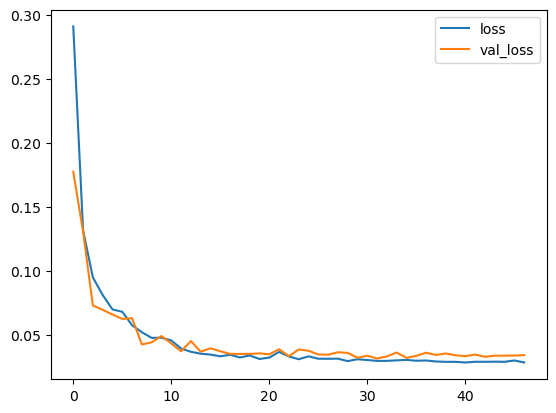

In [23]:
for key in ['loss', 'val_loss']:
    plt.plot(history.history[key],label=key)
plt.legend()
plt.show()

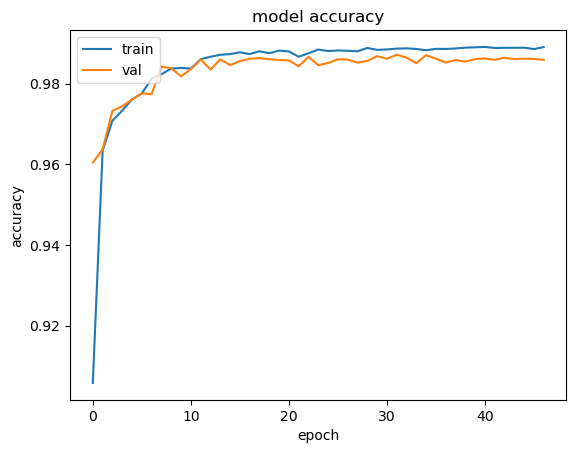

In [24]:
#plot history
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
    
    

In [25]:
#read test
path = 'C:\\Users\\James\\hwk03_data_new\\test\\pre'
os.chdir(path)
test = []
for i in range(301,401):
    img = Image.open('frame'+str(i)+'.bmp')
    img = np.array(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.uint8)
    img = img[61:567,10:550]
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)# 
    img = cv2.equalizeHist(img) 
    img = img / 255  #歸一化
    img = cv2.merge((img,img,img))
    test.append(img)

In [26]:
test=np.array(test)

In [27]:
test.shape

(100, 224, 224, 3)

In [28]:
y_pred = model.predict(test,batch_size=8)

In [29]:
y_pred.shape

(100, 224, 224, 2)

In [30]:
y_pred = np.argmax(y_pred, axis=3) # 改成one channel

In [31]:
y_pred.shape

(100, 224, 224)

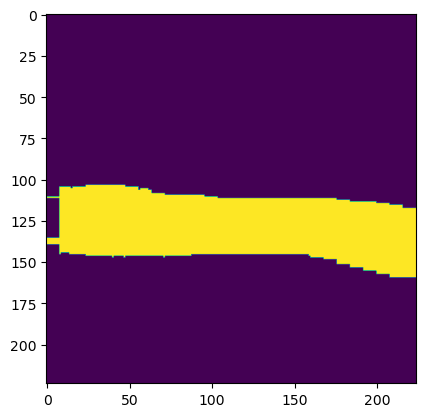

In [32]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(y_pred[2])
plt.show()

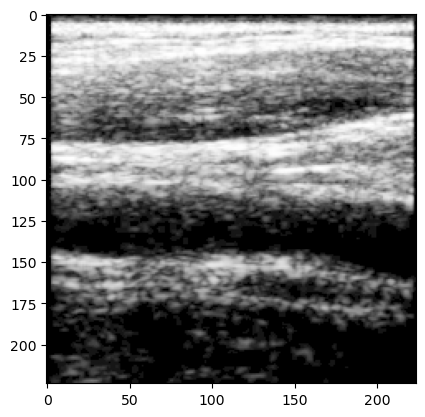

In [33]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(test[2])
plt.show()

In [34]:
#輸出成jpg
from PIL import Image
for i in range(100):
    img = y_pred[i]
    img = np.array(img)
    img = img*255
    img = Image.fromarray(img.astype(np.uint8))
    img.save('C:\\Users\\James\\fcn6\\'+str(i)+'.jpg')


In [74]:
#輸出成bmp
for i in range(100):
    img = y_pred[i]
    img = np.array(img,dtype='uint8') 
    img = cv2.resize(img, (540, 505), interpolation=cv2.INTER_AREA) # 先resize回(505,540)。cv2 和 np 長寬相反要注意
    img = np.pad(img,((61,0),(10,90)),'constant', constant_values=0) #根據先前crop補回0，上方補61 左方補10 右方補90
    img = np.array(img,dtype='bool')# 改為booling
    img = Image.fromarray(img)
    img.save('C:\\Users\\James\\fcn_post\\frame'+str(301+i)+'.bmp_ROI.bmp','bmp')#輸出結果
